In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import cross_val_score

In [3]:
df_data = pd.read_csv(r'C:\Users\chaka\Preethu\My_Git_Repo\Final Project_Rideflow\Datasets\preprocessed_rideflow_datasets.csv')
df_data.head()

,ride_id,driver_id,customer_id,fare_price,surge_multiplier,driver_rating,customer_rating,estimated_eta_min,actual_eta_min,ride_status,...,drop_zone_Adyar,drop_zone_Anna Nagar,drop_zone_OMR,drop_zone_Porur,drop_zone_T Nagar,drop_zone_Tambaram,drop_zone_Velachery,weather_clear,weather_cloudy,weather_rain
0,1,1842,6072,450.514728,1.001779,4.350624,4.037232,11.778023,18.304775,1,...,1,0,0,0,0,0,0,1,0,0
1,2,1186,5942,483.889094,1.193147,4.524196,3.324278,4.430894,13.343961,0,...,0,0,0,0,0,1,0,0,1,0
2,3,1297,5829,382.581291,2.008478,4.054085,4.979153,19.202891,12.039878,0,...,0,0,0,0,0,1,0,0,0,1
3,4,1765,5429,246.018489,1.218528,3.689937,3.099466,18.711931,7.535792,0,...,0,0,0,0,0,0,1,1,0,0
4,5,1565,5079,270.302221,1.497370,3.545512,3.073704,10.786351,12.104096,0,...,0,0,0,0,0,1,0,0,1,0


In [4]:
#checks
print(df_data.duplicated().sum())
print(df_data.isnull().sum())

0
ride_id                   0
driver_id                 0
customer_id               0
fare_price                0
surge_multiplier          0
driver_rating             0
customer_rating           0
estimated_eta_min         0
actual_eta_min            0
ride_status               0
traffic_level             0
driver_active             0
feedback_text             0
hour                      0
day_of_week               0
is_weekend                0
available_drivers         0
distance_km               0
cancellation_risk         0
is_peak_hour              0
eta_diff                  0
ride_count                0
pickup_zone_Adyar         0
pickup_zone_Anna Nagar    0
pickup_zone_OMR           0
pickup_zone_Porur         0
pickup_zone_T Nagar       0
pickup_zone_Tambaram      0
pickup_zone_Velachery     0
drop_zone_Adyar           0
drop_zone_Anna Nagar      0
drop_zone_OMR             0
drop_zone_Porur           0
drop_zone_T Nagar         0
drop_zone_Tambaram        0
drop_zone_Velacher

Feature Selection

In [5]:
#dropping unnecessary columns
df_data.drop(['ride_id','driver_id', 'customer_id' ], axis=1, inplace=True)

In [6]:
#dropping feedback columns as they are needed for model building
df_data.drop('feedback_text', axis=1, inplace=True)

In [7]:
df_data.columns

Index(['fare_price', 'surge_multiplier', 'driver_rating', 'customer_rating',
       'estimated_eta_min', 'actual_eta_min', 'ride_status', 'traffic_level',
       'driver_active', 'hour', 'day_of_week', 'is_weekend',
       'available_drivers', 'distance_km', 'cancellation_risk', 'is_peak_hour',
       'eta_diff', 'ride_count', 'pickup_zone_Adyar', 'pickup_zone_Anna Nagar',
       'pickup_zone_OMR', 'pickup_zone_Porur', 'pickup_zone_T Nagar',
       'pickup_zone_Tambaram', 'pickup_zone_Velachery', 'drop_zone_Adyar',
       'drop_zone_Anna Nagar', 'drop_zone_OMR', 'drop_zone_Porur',
       'drop_zone_T Nagar', 'drop_zone_Tambaram', 'drop_zone_Velachery',
       'weather_clear', 'weather_cloudy', 'weather_rain'],
      dtype='object')

In [ ]:
#Models need to build and its target columns
#Ride Demand Prediction - ride_count
#supply demand Prediction - available drivers
#Driver supply Prediction - surge_multiplier
#Ride cancellation Prediction - ride_status
targets = ['ride_count', 'available_drivers', 'surge_multiplier', 'ride_status']

Model: Ride Demand prediction

In [10]:
#feature selection for ride demand prediction 
#target_variable : 'ride_count' 
X1 = df_data.drop('ride_count', axis=1)
y1 = df_data['ride_count']

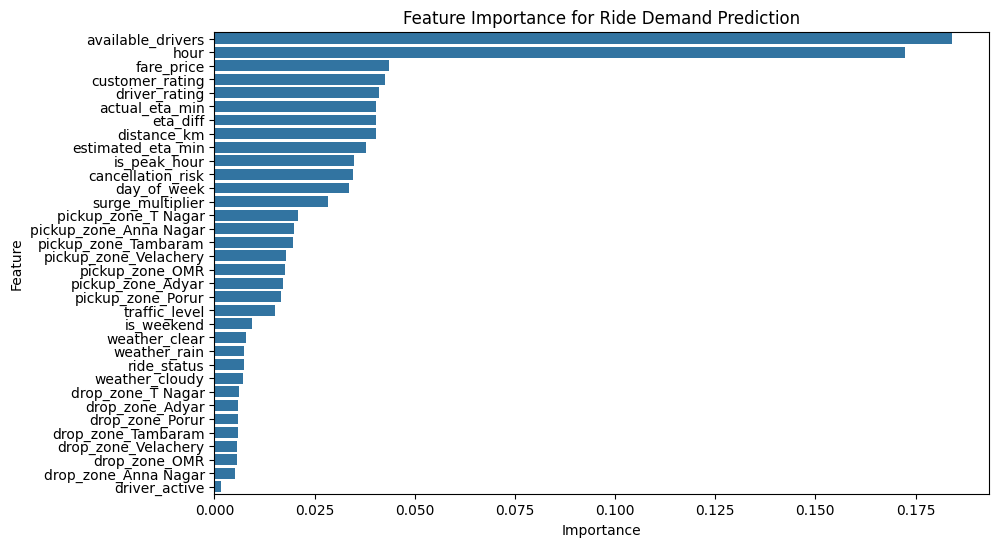

In [11]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X1, y1)
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X1.columns, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance for Ride Demand Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [17]:
features = feature_importance_df['Feature'].tolist()
features

['available_drivers',
 'hour',
 'fare_price',
 'customer_rating',
 'driver_rating',
 'actual_eta_min',
 'eta_diff',
 'distance_km',
 'estimated_eta_min',
 'is_peak_hour',
 'cancellation_risk',
 'day_of_week',
 'surge_multiplier',
 'pickup_zone_T Nagar',
 'pickup_zone_Anna Nagar',
 'pickup_zone_Tambaram',
 'pickup_zone_Velachery',
 'pickup_zone_OMR',
 'pickup_zone_Adyar',
 'pickup_zone_Porur',
 'traffic_level',
 'is_weekend',
 'weather_clear',
 'weather_rain',
 'ride_status',
 'weather_cloudy',
 'drop_zone_T Nagar',
 'drop_zone_Adyar',
 'drop_zone_Porur',
 'drop_zone_Tambaram',
 'drop_zone_Velachery',
 'drop_zone_OMR',
 'drop_zone_Anna Nagar',
 'driver_active']

In [18]:
#removing available _drivers feature as it is showing multi collinearity with drivers_count
#removing after ride features and retaining the top features plus pickup_zone for model building
final_features1 = ['hour', 'day_of_week', 'is_weekend', 'is_peak_hour', 'surge_multiplier',
'pickup_zone_T Nagar',
 'pickup_zone_Anna Nagar',
 'pickup_zone_Tambaram',
 'pickup_zone_Velachery',
 'pickup_zone_OMR',
 'pickup_zone_Adyar',
 'pickup_zone_Porur', 'traffic_level', 'weather_clear', 'weather_cloudy', 'weather_rain']


In [19]:
X1_final = X1[final_features1]

In [20]:
#train test split
X1_train, X1_test, y1_train, y1_test = train_test_split(X1_final, y1, test_size=0.2, random_state=42)

In [21]:
X1_train.shape, X1_test.shape, y1_train.shape, y1_test.shape

((40000, 16), (10000, 16), (40000,), (10000,))

In [22]:
#baseline model building using linear regression
linear = LinearRegression()
linear.fit(X1_train, y1_train)
y1_pred_linear = linear.predict(X1_test)
mse_linear = mean_squared_error(y1_test, y1_pred_linear)
rmse_linear = root_mean_squared_error(y1_test, y1_pred_linear)
r2_linear = r2_score(y1_test, y1_pred_linear)
print(f"Linear Regression - RMSE: {rmse_linear}, R2 Score: {r2_linear}")


Linear Regression - RMSE: 97.20005482363453, R2 Score: 0.07313378149909255


In [23]:
#model building using random forest regressor
rfr = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rfr.fit(X1_train, y1_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
y1_pred_rfr = rfr.predict(X1_test)
mse_rfr = mean_squared_error(y1_test, y1_pred_rfr)
rmse_rfr = root_mean_squared_error(y1_test, y1_pred_rfr)
r2_rfr = r2_score(y1_test, y1_pred_rfr)
print(f"Random Forest Regressor - RMSE: {rmse_rfr}, R2 Score: {r2_rfr}")

Random Forest Regressor - RMSE: 28.19449355340514, R2 Score: 0.9220147210726806


In [25]:
#model building using xgboost regressor
xgb = XGBRegressor(
    n_estimators=100,
    max_depth=10,  
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)
xgb.fit(X1_train, y1_train)
y1_pred_xgb = xgb.predict(X1_test)
mse_xgb = mean_squared_error(y1_test, y1_pred_xgb)
rmse_xgb = root_mean_squared_error(y1_test, y1_pred_xgb)
r2_xgb = r2_score(y1_test, y1_pred_xgb)
print(f"XGBoost Regressor - RMSE: {rmse_xgb}, R2 Score: {r2_xgb}")

XGBoost Regressor - RMSE: 0.8812715411186218, R2 Score: 0.999923825263977


In [26]:
#print all the scores together for comparison
print(f"Linear Regression - RMSE: {rmse_linear}, R2 Score: {r2_linear}")
print(f"Random Forest Regressor - RMSE: {rmse_rfr}, R2 Score: {r2_rfr}")
print(f"XGBoost Regressor - RMSE: {rmse_xgb}, R2 Score: {r2_xgb}")

Linear Regression - RMSE: 97.20005482363453, R2 Score: 0.07313378149909255
Random Forest Regressor - RMSE: 28.19449355340514, R2 Score: 0.9220147210726806
XGBoost Regressor - RMSE: 0.8812715411186218, R2 Score: 0.999923825263977


In [31]:
#cross validation for random forest regressor
cv_scores_rfr = cross_val_score(rfr, X1_final, y1, cv=5, scoring='r2')
print(f"Random Forest Regressor - Cross-Validated R2 Scores: {cv_scores_rfr}")

Random Forest Regressor - Cross-Validated R2 Scores: [0.93750432 0.92800164 0.9234546  0.92899963 0.91341905]


XGBoost is overfitting, Linear Regression is underfitting, and Random Forest is realistic for a production environment thus been choosen as final model since it is
Stable
Interpretable
Realistic

In [28]:
#save the best model in new folder named 'Saved_models' in the repo
import pickle
best_model = rfr  # Random Forest is the best model based on evaluation metrics
with open(r'C:\Users\chaka\Preethu\My_Git_Repo\Final Project_Rideflow\Saved_models\Demand_pred_rfr_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

2. Driver Supply Prediction
Target variable - avaiable_drivers

In [32]:
#defining X2 and y2 for supply demand prediction
X2 = df_data.drop('available_drivers', axis=1)
y2 = df_data['available_drivers']

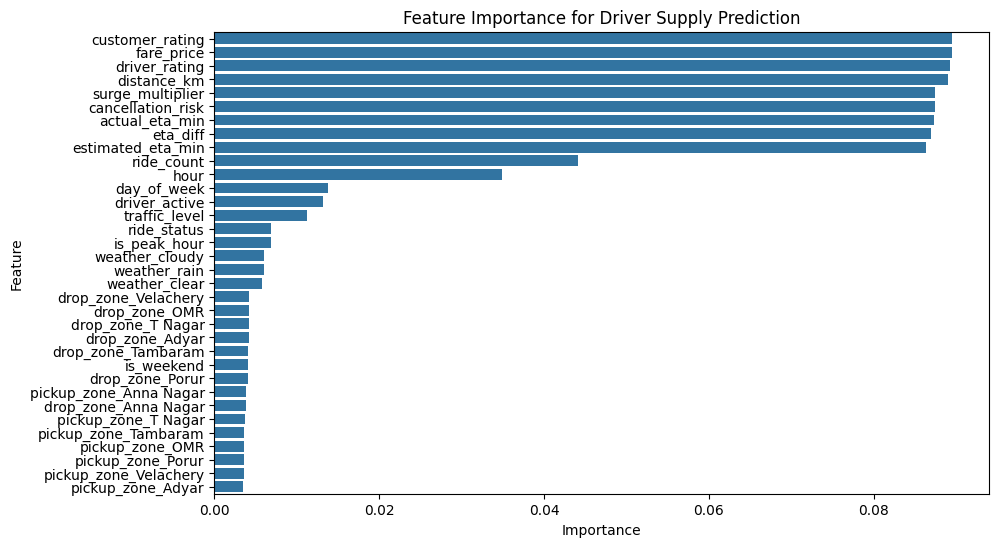

In [35]:
#Feature importance using random forest classifier for supply demand prediction
model_2 = RandomForestClassifier(n_estimators=100, random_state=42)
model_2.fit(X2, y2)
importances_2 = model_2.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X2.columns, 'Importance': importances_2})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance for Driver Supply Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()
plt.close()

In [40]:
features2 = feature_importance_df['Feature'].tolist()
features2

['customer_rating',
 'fare_price',
 'driver_rating',
 'distance_km',
 'surge_multiplier',
 'cancellation_risk',
 'actual_eta_min',
 'eta_diff',
 'estimated_eta_min',
 'ride_count',
 'hour',
 'day_of_week',
 'driver_active',
 'traffic_level',
 'ride_status',
 'is_peak_hour',
 'weather_cloudy',
 'weather_rain',
 'weather_clear',
 'drop_zone_Velachery',
 'drop_zone_OMR',
 'drop_zone_T Nagar',
 'drop_zone_Adyar',
 'drop_zone_Tambaram',
 'is_weekend',
 'drop_zone_Porur',
 'pickup_zone_Anna Nagar',
 'drop_zone_Anna Nagar',
 'pickup_zone_T Nagar',
 'pickup_zone_Tambaram',
 'pickup_zone_OMR',
 'pickup_zone_Porur',
 'pickup_zone_Velachery',
 'pickup_zone_Adyar']

In [41]:
#keeping relevant features - preride and real-time features for supply demand prediction
final_features2 = ['hour', 'day_of_week', 'is_weekend', 'ride_count', 'is_peak_hour', 'surge_multiplier', 'traffic_level', 'weather_clear', 'weather_cloudy', 'weather_rain', 'pickup_zone_T Nagar', 'pickup_zone_Anna Nagar', 'pickup_zone_Tambaram', 'pickup_zone_Velachery', 'pickup_zone_OMR', 'pickup_zone_Adyar', 'pickup_zone_Porur']

In [42]:
#train test split for supply demand prediction
X2_final = X2[final_features2]
X2_train, X2_test, y2_train, y2_test = train_test_split(X2_final, y2, test_size=0.2, random_state=42)

In [43]:
#baseline model building using linear regression for supply demand prediction
linear_2 = LinearRegression()
linear_2.fit(X2_train, y2_train)
y2_pred_linear = linear_2.predict(X2_test)
mse_linear_2 = mean_squared_error(y2_test, y2_pred_linear)
rmse_linear_2 = root_mean_squared_error(y2_test, y2_pred_linear)
r2_linear_2 = r2_score(y2_test, y2_pred_linear)
print(f"Linear Regression - RMSE: {rmse_linear_2}, R2 Score: {r2_linear_2}")

Linear Regression - RMSE: 13.759331382209892, R2 Score: 0.9409995179014754


In [44]:
#random forest regressor for supply demand prediction
rfr_2 = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rfr_2.fit(X2_train, y2_train)
y2_pred_rfr = rfr_2.predict(X2_test)
mse_rfr_2 = mean_squared_error(y2_test, y2_pred_rfr)
rmse_rfr_2 = root_mean_squared_error(y2_test, y2_pred_rfr)
r2_rfr_2 = r2_score(y2_test, y2_pred_rfr)
print(f"Random Forest Regressor - RMSE: {rmse_rfr_2}, R2 Score: {r2_rfr_2}")

Random Forest Regressor - RMSE: 2.657607857684483, R2 Score: 0.99779888518014


In [45]:
#xgboost regressor for supply demand prediction
xgb_2 = XGBRegressor(
    n_estimators=100,
    max_depth=10,  
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)
xgb_2.fit(X2_train, y2_train)
y2_pred_xgb = xgb_2.predict(X2_test)
mse_xgb_2 = mean_squared_error(y2_test, y2_pred_xgb)
rmse_xgb_2 = root_mean_squared_error(y2_test, y2_pred_xgb)
r2_xgb_2 = r2_score(y2_test, y2_pred_xgb)
print(f"XGBoost Regressor - RMSE: {rmse_xgb_2}, R2 Score: {r2_xgb_2}")  

XGBoost Regressor - RMSE: 1.7805265188217163, R2 Score: 0.9990119934082031


In [46]:
#print all the scores together for comparison
print(f"Linear Regression - RMSE: {rmse_linear_2}, R2 Score : {r2_linear_2}")
print(f"Random Forest Regressor - RMSE: {rmse_rfr_2}, R2 Score: {r2_rfr_2}")
print(f"XGBoost Regressor - RMSE: {rmse_xgb_2}, R2 Score: {r2_xgb_2}")

Linear Regression - RMSE: 13.759331382209892, R2 Score : 0.9409995179014754
Random Forest Regressor - RMSE: 2.657607857684483, R2 Score: 0.99779888518014
XGBoost Regressor - RMSE: 1.7805265188217163, R2 Score: 0.9990119934082031


In [47]:
#cross validation for random forest regressor, removing ride_count(highly correlated feature)
X2_final_no_ride_count = X2_final.drop('ride_count', axis=1)
cv_scores_rfr_no_ride_count = cross_val_score(rfr_2, X2_final_no_ride_count, y2, cv=5, scoring='r2')
print(f"Random Forest Regressor (without ride_count) - Cross-Validated R2 Scores: {cv_scores_rfr_no_ride_count}")


Random Forest Regressor (without ride_count) - Cross-Validated R2 Scores: [0.90249254 0.90777765 0.89559239 0.90516307 0.90260334]


In [48]:
#cross validation for Xgboost regressor, removing ride_count(highly correlated feature)
cv_scores_xgb_no_ride_count = cross_val_score(xgb_2, X2_final_no_ride_count, y2, cv=5, scoring='r2')
print(f"XGBoost Regressor (without ride_count) - Cross-Validated R2 Scores: {cv_scores_xgb_no_ride_count}")


XGBoost Regressor (without ride_count) - Cross-Validated R2 Scores: [0.99861276 0.99841803 0.99811101 0.99857253 0.9983179 ]


Initially, the model showed very high accuracy due to strong dependence on demand-related features. After removing highly correlated variables, the Random Forest model achieved a stable R² of around 0.90 using only pre-ride features, making it robust and suitable for real-world deployment.”

In [49]:
#saving the best model for supply demand prediction
best_model_2 = rfr_2  # Random Forest is the best model based on evaluation metrics
with open(r'C:\Users\chaka\Preethu\My_Git_Repo\Final Project_Rideflow\Saved_models\Supply_pred_rfr_model.pkl', 'wb') as f:
    pickle.dump(best_model_2, f)

Dynamic Pricing - Demand - Supply Gap

predition variables of demand and supply model
y1_pred_rfr
y2_pred_rfr


In [54]:
predicted_demand = rfr.predict(X1_final)[0]
predicted_supply = rfr_2.predict(X2_final)[0]

In [57]:
#calculate surge multiplier using predicted demand and supply
def calculate_surge_advanced(demand, supply, base_fare,
                             traffic_level, weather, is_peak_hour):
    
    demand = max(0, predicted_demand)
    supply = max(1, predicted_supply)
    #Gap/Gap ratio calculation
    gap = demand - supply
    gap_ratio = gap / (supply + 1)
    #base surge calculation using gap ratio
    alpha = 0.5
    surge = 1 + (0.5 * gap_ratio)
    
    # Context adjustments
    if traffic_level == "High":
        surge += 0.2
    if weather in ["Rain", "Storm"]:
        surge += 0.3
    if is_peak_hour:
        surge += 0.2
    
#Final prediction
    surge = max(0.8, min(surge, 3.0))
    final_price = base_fare * surge
    
    return round(surge, 2), round(final_price, 2)

In [58]:
#sample calculation for surge multiplier and final price
alpha = 0.5
surge, price = calculate_surge_advanced(
                                        demand=180,
                                        supply=120,
                                        base_fare=200,
                                        traffic_level="High",
                                        weather="Rain",
                                        is_peak_hour=True
                                        )

print("Surge Multiplier:", surge)
print("Final Price:", price)

Surge Multiplier: 1.92
Final Price: 384.66


In [59]:
#pickle the surge calculation function for deployment
with open(r'C:\Users\chaka\Preethu\My_Git_Repo\Final Project_Rideflow\Saved_models\surge_calculation_function.pkl', 'wb') as f:
    pickle.dump(calculate_surge_advanced, f)

Model:4 Ride Cancellation Prediction

In [60]:
#target variable for ride cancellation prediction: 'ride_status'
X4 = df_data.drop('ride_status', axis=1)
y4 = df_data['ride_status']

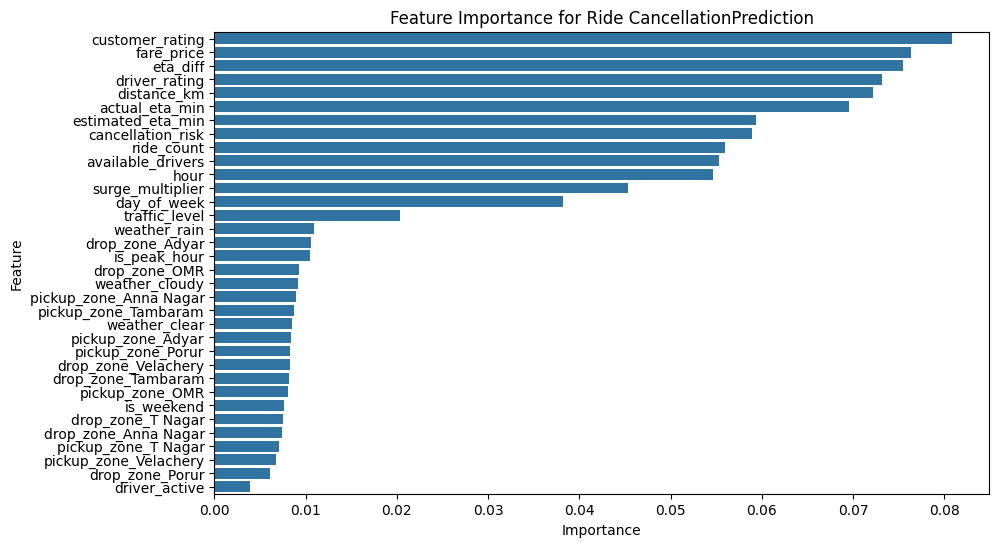

In [63]:
#feature selection for ride cancellation prediction using random forest classifier
model_4 = RandomForestClassifier(n_estimators=100, random_state=42)
model_4.fit(X4, y4)
importances = model_4.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X4.columns, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance for Ride CancellationPrediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


In [62]:
features4 = feature_importance_df['Feature'].tolist()
features4

['customer_rating',
 'fare_price',
 'eta_diff',
 'driver_rating',
 'distance_km',
 'actual_eta_min',
 'estimated_eta_min',
 'cancellation_risk',
 'ride_count',
 'available_drivers',
 'hour',
 'surge_multiplier',
 'day_of_week',
 'traffic_level',
 'weather_rain',
 'drop_zone_Adyar',
 'is_peak_hour',
 'drop_zone_OMR',
 'weather_cloudy',
 'pickup_zone_Anna Nagar',
 'pickup_zone_Tambaram',
 'weather_clear',
 'pickup_zone_Adyar',
 'pickup_zone_Porur',
 'drop_zone_Velachery',
 'drop_zone_Tambaram',
 'pickup_zone_OMR',
 'is_weekend',
 'drop_zone_T Nagar',
 'drop_zone_Anna Nagar',
 'pickup_zone_T Nagar',
 'pickup_zone_Velachery',
 'drop_zone_Porur',
 'driver_active']

In [65]:
#keeping relevant features for ride cancellation prediction
final_features4 = features = [
    'customer_rating',
    'fare_price',
    'eta_diff',
    'driver_rating',
    'distance_km',
    'estimated_eta_min',
    'hour',
    'day_of_week',
    'traffic_level',
    'weather_clear',
    'weather_cloudy',
    'weather_rain',
    'is_peak_hour'
]

X4_final = X4[final_features4]
y4_final = y4


In [66]:
#train test split for ride cancellation prediction
X4_train, X4_test, y4_train, y4_test = train_test_split(X4_final, y4_final, test_size=0.2, random_state=42) 

In [67]:
#shape checks
X4_train.shape, X4_test.shape, y4_train.shape, y4_test.shape

((40000, 13), (10000, 13), (40000,), (10000,))

In [69]:
#base line logistic regression model
logistic = LogisticRegression(max_iter=1000)
logistic.fit(X4_train, y4_train)
y4_pred_logistic = logistic.predict(X4_test)
print("Logistic Regression Classification Report:")
print(classification_report(y4_test, y4_pred_logistic))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.77      1.00      0.87      7718
           1       0.00      0.00      0.00      2282

    accuracy                           0.77     10000
   macro avg       0.39      0.50      0.44     10000
weighted avg       0.60      0.77      0.67     10000



c:\Users\chaka\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chaka\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chaka\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [70]:
#decistion tree classifier for ride cancellation prediction
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X4_train, y4_train)
y4_pred_dtc = dtc.predict(X4_test)
print("Decision Tree Classifier Classification Report:")
print(classification_report(y4_test, y4_pred_dtc))

Decision Tree Classifier Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.96      7718
           1       0.84      0.87      0.86      2282

    accuracy                           0.93     10000
   macro avg       0.90      0.91      0.91     10000
weighted avg       0.93      0.93      0.93     10000



In [71]:
#random forest classifier for ride cancellation prediction
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(X4_train, y4_train)
y4_pred_rfc = rfc.predict(X4_test)
print("Random Forest Classifier Classification Report:")
print(classification_report(y4_test, y4_pred_rfc))

Random Forest Classifier Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      7718
           1       0.97      0.90      0.94      2282

    accuracy                           0.97     10000
   macro avg       0.97      0.95      0.96     10000
weighted avg       0.97      0.97      0.97     10000



In [74]:
#xgboost classifier for ride cancellation prediction
xgb_clf = XGBRegressor(
    n_estimators=100,
    max_depth=10,  
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)
xgb_clf.fit(X4_train, y4_train)
y4_pred_xgb = xgb_clf.predict(X4_test)
print(f"XGBoost Regressor Accuracy: {r2_score(y4_test, y4_pred_xgb)}")
print(classification_report(y4_test, y4_pred_xgb.round()))

XGBoost Regressor Accuracy: 0.8199292421340942
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      7718
           1       0.96      0.90      0.93      2282

    accuracy                           0.97     10000
   macro avg       0.97      0.94      0.96     10000
weighted avg       0.97      0.97      0.97     10000



In [75]:
#print acuracy scores for all models together for comparison
print(f"Logistic Regression Accuracy: {accuracy_score(y4_test, y4_pred_logistic)}")
print(f"Decision Tree Classifier Accuracy: {accuracy_score(y4_test, y4_pred_dtc)}")
print(f"Random Forest Classifier Accuracy: {accuracy_score(y4_test, y4_pred_rfc)}")
print(f"XGBoost Classifier Accuracy: {accuracy_score(y4_test, y4_pred_xgb.round())}")

Logistic Regression Accuracy: 0.7718
Decision Tree Classifier Accuracy: 0.934
Random Forest Classifier Accuracy: 0.9716
XGBoost Classifier Accuracy: 0.9692


In [76]:
#cross validation for random forest classifier
cv_scores_rfc = cross_val_score(rfc, X4_final, y4_final, cv=5, scoring='accuracy')
print(f"Random Forest Classifier - Cross-Validated Accuracy Scores: {cv_scores_rfc}")

Random Forest Classifier - Cross-Validated Accuracy Scores: [0.9695 0.9688 0.9707 0.9694 0.9696]


In [77]:
#saving the best model for ride cancellation prediction
best_model_4 = rfc  # Random Forest is the best model based on evaluation metrics
with open(r'C:\Users\chaka\Preethu\My_Git_Repo\Final Project_Rideflow\Saved_models\Cancellation_pred_rfc_model.pkl', 'wb') as f:
    pickle.dump(best_model_4, f)

#summary of ML 
Required libraries imported
Data collection - preprocessed
Feature selection:
    Unnecessary columns - (Ids, Feedback text) removed
Model building
    1. Demand Prediction
        ○ Target: ride_count
        ○ Features importance checked and features which are relevant were taken for training
        ○ Train test split
        ○ Model train and fit
            § Linear regression - baseline
            § Random forest regressor
            § XGBoost reagressor
        ○ Best performed model - random forest 92% r2score
        ○ Although XGB had higher score, it may suspect to overfitting, so considered RFR
        ○ Model saved
    2. Supply Prediction
        a. Target: available_drivers
        ○ Features importance checked and features which are relevant were taken for training
        ○ Train test split
        ○ Model train and fit
            § Linear regression - baseline
            § Random forest regressor
            § XGBoost reagressor
        ○ Best performed model - random forest 99% r2 score
        ○ Cross validated by removing ride_count(highly correalted feature)
        ○ Initially, the model showed very high accuracy due to strong dependence on demand-related features. After removing highly correlated variables, the Random Forest model achieved a stable R² of around 0.90 using only pre-ride features, making it robust and suitable for real-world deployment.
        ○ Model saved
    3. Dynamic pricing - Demand supply gap
        a. Target: surge_multiplier
        b. Predictions from pervious model are inputs here + fare 
        c. Gap, gap ratio of demand and supply were calculated. A function was created for surge and pricing. 
        d. Tested with sample values
        e. Pickled the results
    4. Ride Cancellation Prediction
        a. Target: ride_status - classifier problem
        b. Feature imporatnace
        c. Top and relevant features were used
        d. Train test split
        e. Model train and fit
            i. Logistic regression - baseline
            ii. Decision tree
            iii. Randomforest classifier
            iv. XGB classifier
        f. Random forest performed well, compared all other models with 97% accuracy.
        g. Model saved

Key insights:
    
multi-model ML system that solves 4 core problems:

📊 Demand Prediction
        Demand(ride_count) is non-linear, thus Tree models outperform linear models. XGBoost captures complex interactions extremely well, but suspect to overfitting. Also ride_count may depend on future information. 
        Best model: Random forest regressor
🚗 Supply Prediction
        Supply depends on time + demand + location. Random forest perfomed well, and was stable even when highly dependent feature was excluded in training.
💰 Surge Pricing
        Surge and price calculated from predictions of demand and supply. Function has been created.
        Additionally added fare prices, Traffic and Time features as conditions for surge prices.
❌ Cancellation Prediction
        Cancellations are driven by delay and user experience, not just location. 
        RF classifier acheived 97% accuracy with real time features.


High Impacted features:
    eta_diff
    is_peak_hour
    day_of_week
    hour
    ride_count
    available_drivers
    fare
    Customer_rating
    traffic
    weather
    Pickupzones
